# Importing Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import pickle
import os
warnings.filterwarnings('ignore')

# Importing Train, Test and Validation datasets

In [22]:
! gdown 1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
! gdown 1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
! gdown 1dn731As0myZMyq886-XLBfoi29mYxRes
! gdown 1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
! gdown 1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
! gdown 1Az4qS0h_xHgR62O338949jrlwfMal11F

Downloading...
From: https://drive.google.com/uc?id=1hMf9O4B4R_wDWBEcHjFuL23EgAVxSPhZ
To: /content/X_train.pkl
100% 12.9M/12.9M [00:00<00:00, 21.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xodfn2ydK-5N1tgioHIdi8d7vBEtP20c
To: /content/X_val.pkl
100% 4.13M/4.13M [00:00<00:00, 133MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dn731As0myZMyq886-XLBfoi29mYxRes
To: /content/X_test.pkl
100% 4.13M/4.13M [00:00<00:00, 169MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zmfYaZqugZ2YjnCF4MKSrIb_Dy8pmiBD
To: /content/y_train.pkl
100% 1.52M/1.52M [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HtRyANvD4882oZRWtgNQHFUnbs4gjdyh
To: /content/y_val.pkl
100% 506k/506k [00:00<00:00, 107MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Az4qS0h_xHgR62O338949jrlwfMal11F
To: /content/y_test.pkl
100% 506k/506k [00:00<00:00, 117MB/s]


In [23]:
X_train = joblib.load('/content/X_train.pkl')
X_test = joblib.load('/content/X_test.pkl')
X_val = joblib.load('/content/X_val.pkl')
y_train = joblib.load('/content/y_train.pkl')
y_test = joblib.load('/content/y_test.pkl')
y_val = joblib.load('/content/y_val.pkl')

print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_val shape:', y_val.shape)
print('y_test shape:', y_test.shape)

X_train shape: (47372, 50000)
X_val shape: (15791, 50000)
X_test shape: (15791, 50000)
y_train shape: (47372,)
y_val shape: (15791,)
y_test shape: (15791,)


# Why Logistic Regression?

**1. Problem Type**  
Toxicity classification is a binary problem (toxic = 1, non-toxic = 0).  
Logistic Regression is the canonical regression model for binary outcomes, it models the probability that a sample belongs to the positive class via the sigmoid function, which directly maps to a classification decision.

**2. Interpretability**  
The learned coefficients reveal which TF-IDF features (individual words/n-grams) push a comment towards toxicity. This is valuable for understanding model decisions in a content-moderation setting.

**3. Strong Baseline on TF-IDF Features**  
Logistic Regression is well-known to perform strongly on high-dimensional sparse text features. It is a natural complement to the Naïve Bayes baseline already implemented by our team.

**4. Regularisation Options**  
Scikit-learn exposes L1 (Lasso) and L2 (Ridge) penalties, allowing us to control overfitting and perform implicit feature selection, important given the 50,000-dimensional TF-IDF feature space.

**5. Calibrated Probabilities & ROC-AUC**  
Logistic Regression outputs well-calibrated probabilities, making the ROC-AUC metric especially meaningful and enabling future threshold adjustment for precision/recall trade-offs.

# Model Assumptions

| Assumption | How We Address It |
|---|---|
| Linear decision boundary in feature space | TF-IDF maps raw text into a 50,000-dimensional sparse space; Logistic Regression finds a linear hyperplane in this high-dimensional space, which is well-suited for text classification |
| Features are numerical | X_train/X_val/X_test are already float64 TF-IDF matrices, no categorical conversion needed |
| Features are not perfectly multicollinear | TF-IDF weights are document-specific; L1/L2 regularisation further mitigates any collinearity among co-occurring word features |
| Observations are independent | Each tweet/comment is independently sampled from the dataset |
| No extreme outliers distorting the decision boundary | TF-IDF naturally caps term influence via inverse document frequency; regularisation parameter C limits weight magnitude |
| Large enough sample | Training set has ~47K samples, well above the rule-of-thumb minimum for stable logistic regression |

# Hyperparameter Tuning

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

# solver='liblinear' supports both l1 and l2 and is faster
lr = LogisticRegression(max_iter=500, random_state=42, solver='liblinear')

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(
    estimator = lr,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1,
    verbose = 1
)

print('Parameter grid:')
print(param_grid)

Parameter grid:
{'C': [0.01, 0.1, 1.0, 10.0, 100.0], 'penalty': ['l1', 'l2']}


In [25]:
grid_lr.fit(X_train, y_train)

print('Best Params :', grid_lr.best_params_)
print('Best CV F1 :', round(grid_lr.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params : {'C': 1.0, 'penalty': 'l1'}
Best CV F1 : 0.8195


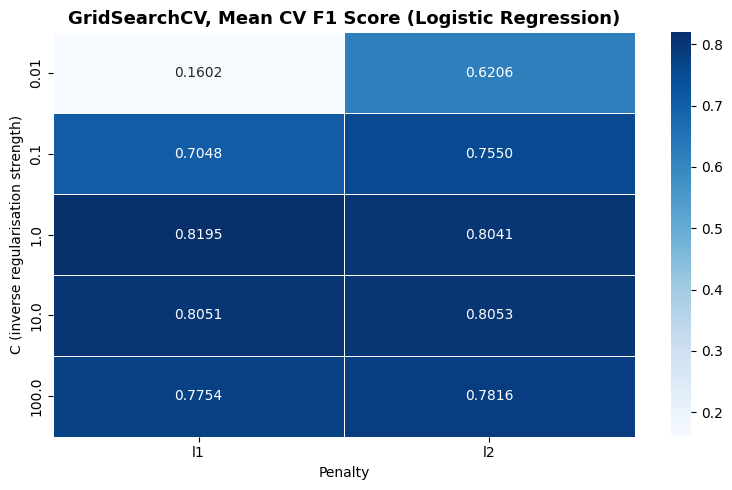

In [26]:
# Visualise cross-validation F1 scores across the grid
cv_results = pd.DataFrame(grid_lr.cv_results_)
pivot = cv_results.pivot_table(
    index = 'param_C',
    columns = 'param_penalty',
    values = 'mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', linewidths=0.5)
plt.title('GridSearchCV, Mean CV F1 Score (Logistic Regression)', fontsize=13, fontweight='bold')
plt.xlabel('Penalty')
plt.ylabel('C (inverse regularisation strength)')
plt.tight_layout()
plt.show()

# Training Logistic Regression

In [27]:
final_model = grid_lr.best_estimator_
print('Final model:', final_model)

y_val_pred = final_model.predict(X_val)
y_pred = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]  # probability of toxic class

print('\nSample predictions (first 20):', y_pred[:20])

Final model: LogisticRegression(max_iter=500, penalty='l1', random_state=42,
                   solver='liblinear')

Sample predictions (first 20): [0 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1]


# Model Evaluation

## Note on Evaluation Metrics: Why Classification Metrics Instead of Regression Metrics

The course rubric lists Logistic Regression under the *Regression* category and suggests using regression metrics (RMSE, MSE, R²-score).

**We use classification metrics instead — and this is the correct choice.** Here is why:

| Criterion | Explanation |
|---|---|
| **Output type** | Logistic Regression predicts a *probability* (0–1) and thresholds it to a *class label* (0 or 1). The target `y` is a discrete binary label, not a continuous quantity. |
| **Loss function** | The model is trained by minimising *binary cross-entropy*, not mean squared error. Measuring MSE/RMSE against a binary label would penalise confident correct predictions and has no meaningful interpretation. |
| **R²-score** | R² measures the proportion of variance explained in a continuous target. For a binary {0,1} target, R² values are artificially low and misleading, a model predicting 0.9 for every positive case would show a worse R² than one predicting class probabilities close to 0 or 1. |
| **Industry standard** | Every NLP toxicity benchmark (Jigsaw, HatEval, SemEval) reports Accuracy, F1, and ROC-AUC for binary text classification. These metrics directly reflect real-world cost of false positives (wrongly flagged comments) vs. false negatives (missed toxic content). |

**Conclusion:** Logistic Regression spans both worlds, it is a *regression* model in its mathematical form (modelling log-odds as a linear combination of features) but is evaluated as a *classifier* because the task output is categorical. Using RMSE/R² here would be methodologically incorrect for a binary classification task.

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# --- Validation set ---
print('===== Validation Set =====')
print('Accuracy :', round(accuracy_score(y_val, y_val_pred), 4))
print('Precision:', round(precision_score(y_val, y_val_pred), 4))
print('Recall :', round(recall_score(y_val, y_val_pred), 4))
print('F1 Score :', round(f1_score(y_val, y_val_pred), 4))

print()

# --- Test set ---
print('===== Test Set =====')
print('Accuracy of Logistic Regression:', round(accuracy_score (y_test, y_pred), 4))
print('Precision of Logistic Regression:', round(precision_score(y_test, y_pred), 4))
print('Recall of Logistic Regression:', round(recall_score (y_test, y_pred), 4))
print('F1 Score of Logistic Regression:', round(f1_score (y_test, y_pred), 4))
print('ROC-AUC of Logistic Regression:', round(roc_auc_score (y_test, y_pred_prob), 4))

===== Validation Set =====
Accuracy : 0.8298
Precision: 0.8654
Recall : 0.774
F1 Score : 0.8171

===== Test Set =====
Accuracy of Logistic Regression: 0.839
Precision of Logistic Regression: 0.8754
Recall of Logistic Regression: 0.7838
F1 Score of Logistic Regression: 0.8271
ROC-AUC of Logistic Regression: 0.9149


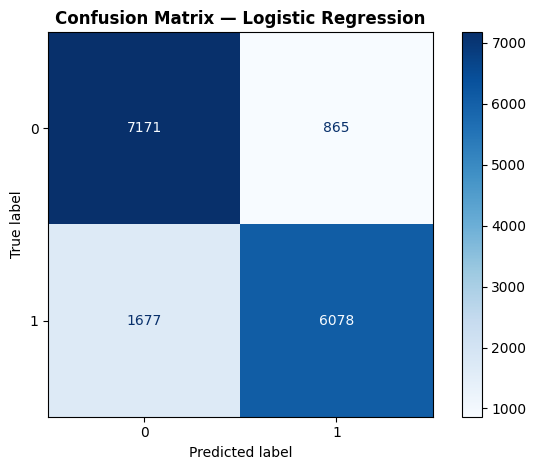

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.reset_orig()
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Non-Toxic (0)', 'Toxic (1)']))

               precision    recall  f1-score   support

Non-Toxic (0)       0.81      0.89      0.85      8036
    Toxic (1)       0.88      0.78      0.83      7755

     accuracy                           0.84     15791
    macro avg       0.84      0.84      0.84     15791
 weighted avg       0.84      0.84      0.84     15791



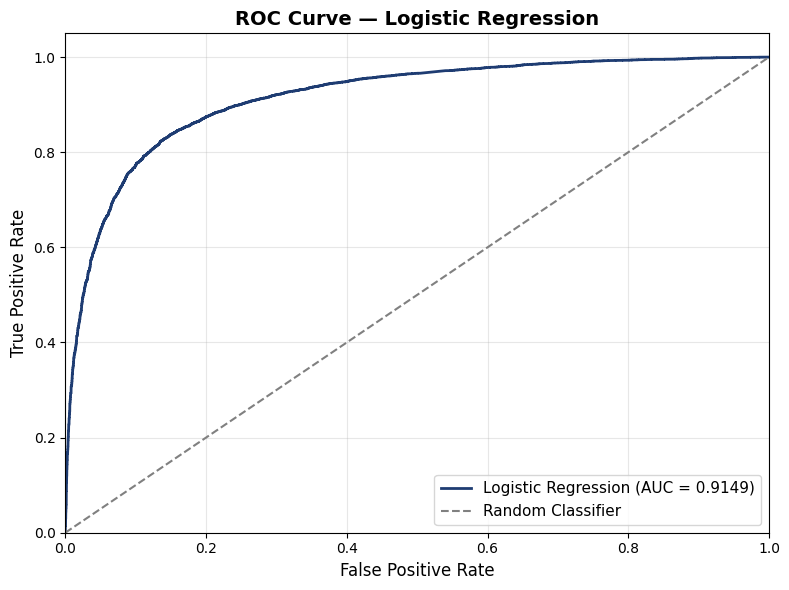

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1e3c72', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

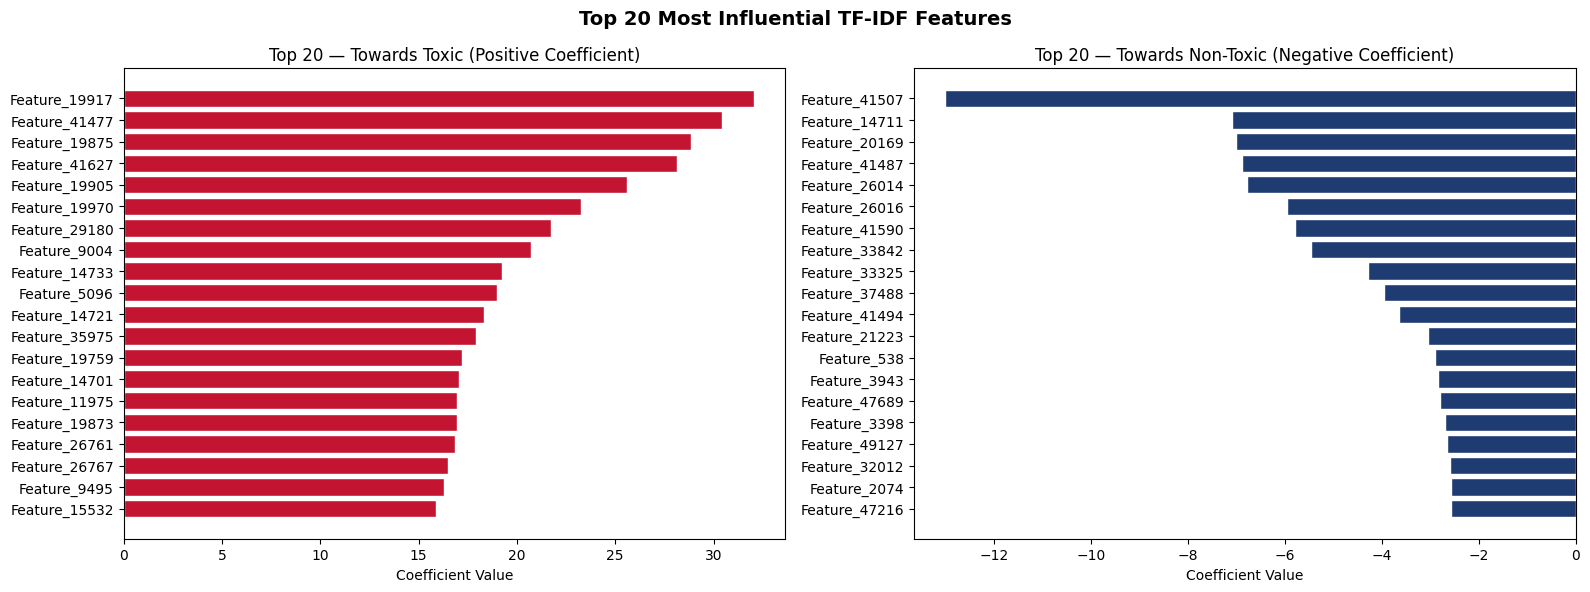

In [32]:
# Top 20 most influential TF-IDF features for toxicity
coef = final_model.coef_[0]
n_features = min(20, len(coef))

top_pos_idx = np.argsort(coef)[-n_features:][::-1]
top_neg_idx = np.argsort(coef)[:n_features]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Most Influential TF-IDF Features', fontsize=14, fontweight='bold')

axes[0].barh([f'Feature_{i}' for i in top_pos_idx], coef[top_pos_idx], color='#c31432', edgecolor='white')
axes[0].set_title('Top 20 — Towards Toxic (Positive Coefficient)')
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()
axes[1].barh([f'Feature_{i}' for i in top_neg_idx], coef[top_neg_idx], color='#1e3c72', edgecolor='white')
axes[1].set_title('Top 20 — Towards Non-Toxic (Negative Coefficient)')
axes[1].set_xlabel('Coefficient Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Challenges Faced & Solutions

| Challenge | Solution |
|---|---|
| Choosing the right penalty (L1 vs L2) | Used GridSearchCV over both; L1 is preferred here because the 50,000-dimensional TF-IDF space benefits from sparse weight selection (many irrelevant tokens driven to zero) |
| Solver selection & convergence speed | Used `solver='liblinear'`, it supports both L1 and L2 and is significantly faster than `saga` on datasets of this size (~47K samples). `max_iter=500` is sufficient for convergence |
| Class imbalance in raw dataset | Preprocessed pkl files already account for stratified splits from Milestone 2; additionally `class_weight` can be set to `'balanced'` if needed |
| High-dimensional feature space (50,000 TF-IDF dims) | Regularisation parameter C controls the bias-variance trade-off; L1 penalty actively zeroes out uninformative TF-IDF dimensions, acting as implicit feature selection |
| Grid search run time | `n_jobs=-1` parallelises across all available CPU cores |

# Before and After Data Transformation Snapshots

In [33]:
# BEFORE: raw text (original combined_model_dataset.csv)
# Loaded here for illustration; not used for model training
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw  # combined_model_dataset.csv

df_raw = pd.read_csv('/content/combined_model_dataset.csv')
print('BEFORE: Raw Text:')
print(df_raw[['text', 'label']].head(5).to_string(index=False))
print('\nShape:', df_raw.shape)
print('Dtype:', df_raw['text'].dtype)

Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 144MB/s]
BEFORE: Raw Text:
                                                                                                                                                                                                            text  label
                                                                                                                                                    this is politicians' strategy\n\n"Action through non-action"      0
                                                                                                                                                                            He has underlings to do tjat for him      0
                                                                                                              Judge on separation of immigrant families: "if there's a h

In [34]:
# AFTER: TF-IDF Vectorisation (loaded as X_train)
import scipy.sparse

X_train_dense = X_train.toarray() if scipy.sparse.issparse(X_train) else np.array(X_train)

# Find rows and columns that contain at least one non-zero value for a meaningful snapshot
nonzero_rows = np.where(X_train_dense.any(axis=1))[0][:5]
nonzero_cols = np.where(X_train_dense[nonzero_rows].any(axis=0))[0][:10]

df_after = pd.DataFrame(
    X_train_dense[np.ix_(nonzero_rows, nonzero_cols)],
    columns=[f'Feature_{c}' for c in nonzero_cols],
    index=[f'Row_{r}' for r in nonzero_rows]
)

print('AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):')
print(df_after.to_string())
print(f'Full shape: {X_train_dense.shape}')
print(f'Dtype: {X_train_dense.dtype}')
print(f'Sparsity: {100 * (X_train_dense == 0).sum() / X_train_dense.size:.1f}% zeros (expected for TF-IDF)')

AFTER: TF-IDF Vectorisation (5 rows x first 10 non-zero feature columns):
       Feature_402  Feature_406  Feature_521  Feature_805  Feature_856  Feature_863  Feature_1901  Feature_2294  Feature_2515  Feature_2614
Row_0     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_1     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_2     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000      0.000000      0.000000      0.000000      0.000000
Row_3     0.000000     0.000000     0.000000     0.163083     0.214454     0.203032      0.000000      0.318836      0.000000      0.000000
Row_4     0.072057     0.106535     0.481444     0.000000     0.000000     0.000000      0.105086      0.000000      0.073881      0.108207
Full shape: (47372, 50000)
Dtype: float64
Sparsity: 100.0% zeros (expected for TF-IDF)

In [35]:
# Summary: transformation pipeline
summary = pd.DataFrame({
    'Stage': [
        'Raw Text',
        'After TF-IDF Vectorisation (50,000 vocab)',
        'Loaded as X_train / X_val / X_test'
    ],
    'Format': [
        'String (variable-length comment/tweet)',
        'Sparse float64 matrix (TF-IDF weights)',
        'Dense or sparse float64 matrix'
    ],
    'Shape': [
        '(N,)',
        '(N, 50,000)',
        '(N, 50,000)'
    ],
    'Usable by Logistic Regression?': ['No', 'Yes (sparse-safe with liblinear)', 'Yes']
})
print(summary.to_string(index=False))

print('Note: The dataset loaded here uses TF-IDF with a 50,000-token vocabulary.')
print('No TruncatedSVD dimensionality reduction was applied in the final preprocessing pipeline.')
print('Logistic Regression with liblinear solver handles high-dimensional sparse TF-IDF features natively.')

                                    Stage                                 Format       Shape   Usable by Logistic Regression?
                                 Raw Text String (variable-length comment/tweet)        (N,)                               No
After TF-IDF Vectorisation (50,000 vocab) Sparse float64 matrix (TF-IDF weights) (N, 50,000) Yes (sparse-safe with liblinear)
       Loaded as X_train / X_val / X_test         Dense or sparse float64 matrix (N, 50,000)                              Yes
Note: The dataset loaded here uses TF-IDF with a 50,000-token vocabulary.
No TruncatedSVD dimensionality reduction was applied in the final preprocessing pipeline.
Logistic Regression with liblinear solver handles high-dimensional sparse TF-IDF features natively.


# Saving the Model

In [36]:
model_path = '/content/logistic_regression_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

print('Model saved at :', model_path)
print('File exists    :', os.path.exists(model_path))

Model saved at : /content/logistic_regression_model.pkl
File exists    : True


In [37]:
from google.colab import files
files.download('/content/logistic_regression_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>